<a href="https://colab.research.google.com/github/alvesferr/dplyr/blob/main/Novo_DoE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Leitura do histórico (usando dados factices)
Histórico carregado (dados factices): 20 linhas x 17 colunas

                                              count        mean         std       min         25%         50%         75%         max
porosity                                       20.0    4.577023    3.076869  0.205845    1.830096    4.032426    7.140529    9.699099
Heating time [hours]                           20.0   45.482896   29.117903  4.645041   19.238637   44.811124   62.994793   96.563203
compression/interface [µm]                     20.0   24.498553   16.539702  1.719426    9.660038   25.381123   40.252823   48.479231
Max stress S1 [MPa]                            20.0  461.058242  314.377577  5.522117  184.267817  373.571509  771.513952  986.886937
Number of interfaces (nbr de pls gravées -1)   20.0    4.950000    2.645254  1.000000    3.000000    5.000000    7.000000    9.000000
Max total heigh of asperities [mm]             20.0    0.216412    0.146629  0.012710 

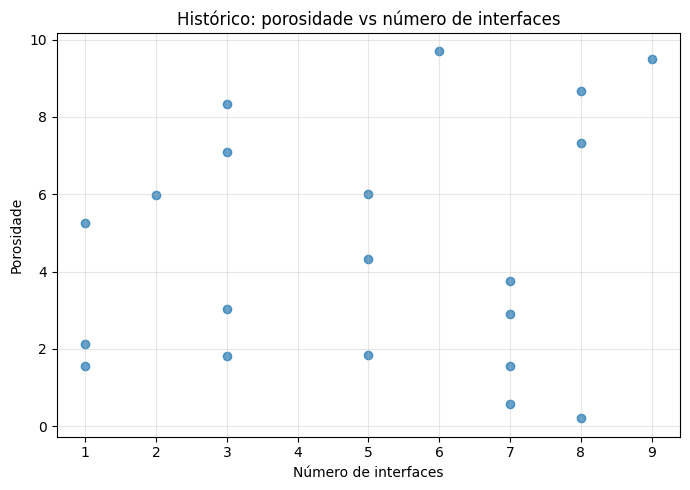

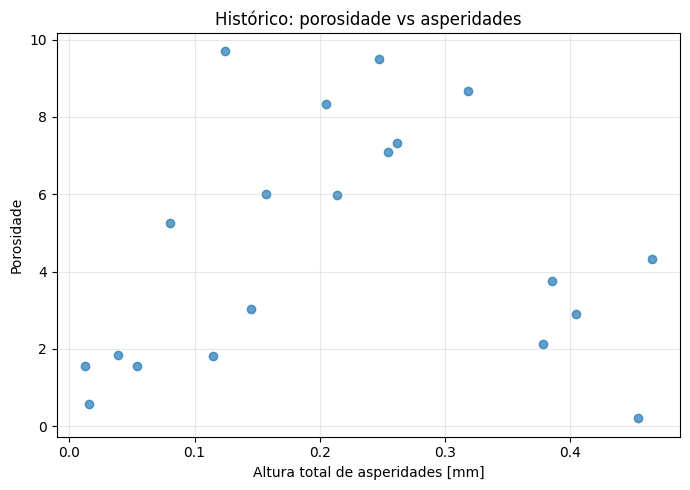

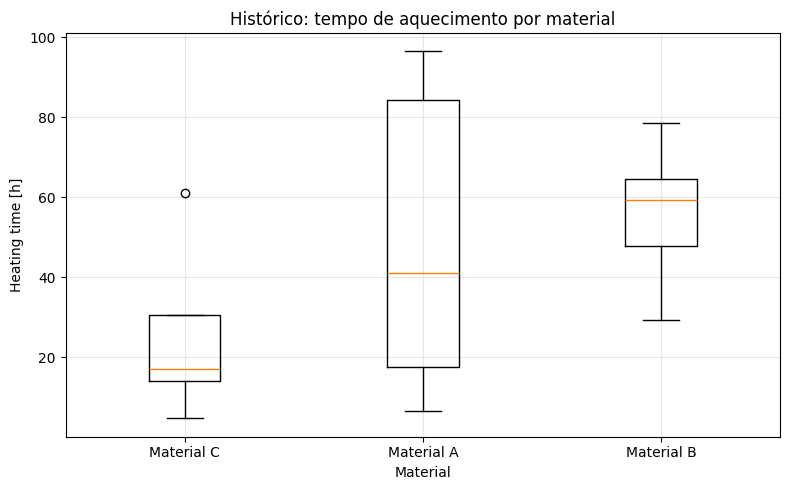


3) Receita / ciclos
[INFO] Receita não encontrada em: /content/Lomond HC File-Rev05.xlsx

Tabela-base (screenshot / fallback):
  ExpID Phase       Program  Tbond_C  tbond_h  Pressure_MPa Atmosphere            Surface  t600_h_PDF  t1100_h_PDF  total_cycle_h
0    A1     A  Multi-step 2     1080        2           5.0     Vacuum             Etched        55.0        107.0     114.483333
1    A2     A  Multi-step 2     1080        2          15.0     Vacuum  Etched+Activation        55.0        107.0     114.483333
2    A3     A  Multi-step 2     1100        4           5.0     Dry Ar  Etched+Activation        55.0        107.0     116.750000
3    A4     A  Multi-step 2     1100        4          15.0     Dry Ar             Etched        55.0        107.0     116.750000
4    B1     B      Setup 17     1100        6           NaN    Best(A)            Best(A)        62.0        108.0     119.750000
5    B2     B  Multi-step 1     1100        6           NaN    Best(A)            Best(A)   

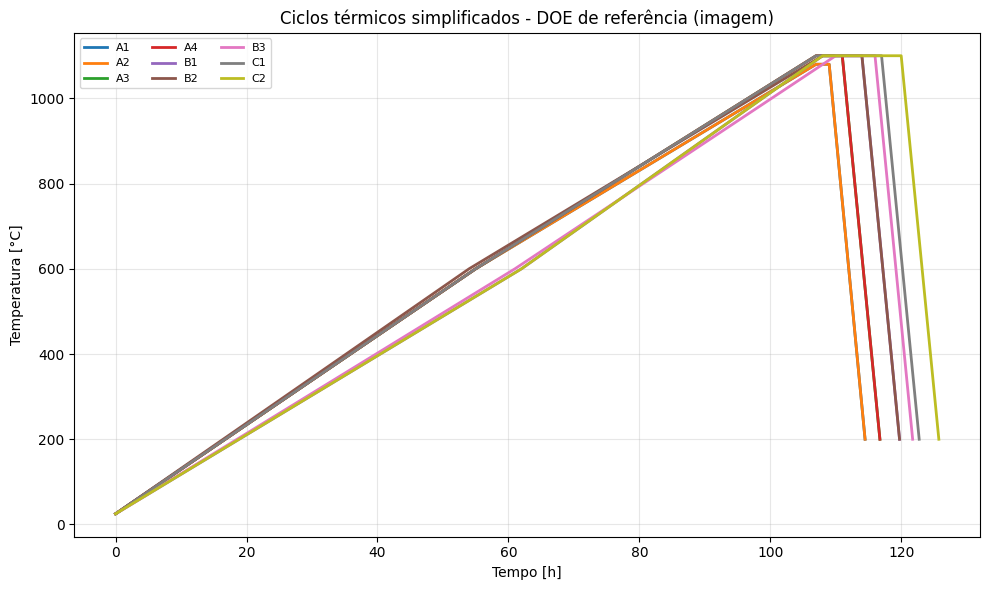


4) Geração do novo DOE
   Phase                   Sample ExpID  Tbond_C  tbond_h  Pressure_MPa Atmosphere            Surface          Program                            NDT                                          Mech  \
0      A       Coupons/Mini-stack    A1     1100      5.0            12     Vacuum             Etched   Multi-step_ref                              —                         Shear + Microhardness   
1      A       Coupons/Mini-stack    A2     1110      7.0             8     Vacuum  Etched+Activation   Multi-step_ref                              —                         Shear + Microhardness   
2      A       Coupons/Mini-stack    A3     1090      7.0            15     Dry Ar  Etched+Activation  Multi-step_fast                              —                         Shear + Microhardness   
3      A       Coupons/Mini-stack    A4     1110      4.0             8     Vacuum             Etched  Multi-step_fast                              —                         Shear 

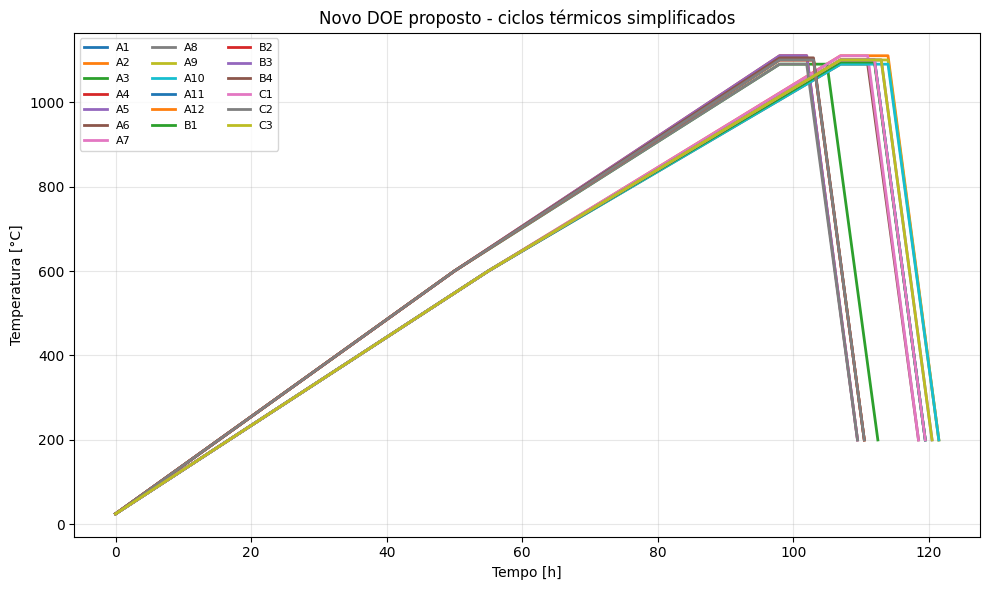


5) Ranking de ganho potencial de produtividade
   ExpID Phase          Program  Tbond_C  tbond_h  Pressure_MPa Atmosphere            Surface  total_cycle_h
3     A4     A  Multi-step_fast     1110      4.0             8     Vacuum             Etched          109.5
4     A5     A  Multi-step_fast     1110      4.0            15     Vacuum  Etched+Activation          109.5
7     A8     A  Multi-step_fast     1090      4.0            15     Dry Ar             Etched          109.5
11   A12     A  Multi-step_fast     1100      5.0            12     Vacuum  Etched+Activation          110.5
13    B2     B  Multi-step_fast     1100      5.0            12     Vacuum  Etched+Activation          110.5
15    B4     B  Multi-step_fast     1105      5.0            15     Vacuum  Etched+Activation          110.5
17    C2     C  Multi-step_fast     1100      5.0            12     Vacuum  Etched+Activation          110.5
2     A3     A  Multi-step_fast     1090      7.0            15     Dry Ar  Etch

In [10]:
# -*- coding: utf-8 -*-
"""
DOE para soldagem por difusão
---------------------------------
Script pensado para Google Colab.

Objetivos:
1) Ler o histórico de dados (CSV) e, se possível, a receita do forno/prensa (Excel);
2) Avaliar variáveis associadas a defeitos (porosidade/severity_index);
3) Gerar gráficos comparativos de ciclos térmicos;
4) Propor um DOE sequencial com metodologia D-optimal (fatores mistos + restrições);
5) Exportar a matriz de DOE em CSV.

Observação importante:
- O arquivo de receita recebido no ambiente desta conversa aparenta estar protegido/encriptado.
  O código abaixo tenta lê-lo; caso não consiga, ele usa uma tabela-exemplo editável
  baseada na imagem fornecida. Se você tiver uma versão não protegida da receita,
  basta substituí-la no caminho indicado.
"""

# =============================
# 1. Instalação e imports
# =============================
# No Colab, descomente se necessário:
# !pip -q install pandas numpy matplotlib scikit-learn patsy openpyxl xlrd

from __future__ import annotations

import io
import os
import re
import math
import warnings
from dataclasses import dataclass
from itertools import product
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from patsy import dmatrix
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


# =============================
# 2. Configuração
# =============================
def first_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[0]

# HISTORICAL_CSV = first_existing_path([
#     "/content/Dados_com_features (1).csv",
#     "/mnt/data/Dados_com_features (1).csv"
# ])
# Commented out the historical CSV path as we're using dummy data.
RECIPE_XLS = first_existing_path([
    "/content/Lomond HC File-Rev05.xlsx",
    "/mnt/data/Lomond HC File-Rev05.xlsx"
])
OUTPUT_DIR = first_existing_path([
    "/mnt/data/doe_output",
    "/content/doe_output"
])
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Se você quiser alterar a região de projeto do DOE, faça aqui.
DOE_FACTORS = {
    "Tbond_C": [1090, 1100, 1110],
    "tbond_h": [4, 5, 6, 7],
    "Pressure_MPa": [8, 12, 15],
    "Atmosphere": ["Vacuum", "Dry Ar"],
    "Surface": ["Etched", "Etched+Activation"],
    "Program": ["Multi-step_ref", "Multi-step_fast"],
}

# Esta tabela replica/condensa o DOE mostrado na imagem anexada.
# Você pode editar os valores conforme a sua realidade.
EXAMPLE_SCREENSHOT_DOE = pd.DataFrame([
    ["A1", "A", "Coupons/Mini-stack", "Multi-step 2", 1080,  2,  5,       "Vacuum",       "Etched",             "—",                              "Shear + Microhardness",                    "OM/SEM interface + porosity", 55.0, 107.0, 114.483333],
    ["A2", "A", "Coupons/Mini-stack", "Multi-step 2", 1080,  2, 15,       "Vacuum",       "Etched+Activation",  "—",                              "Shear + Microhardness",                    "OM/SEM interface + porosity", 55.0, 107.0, 114.483333],
    ["A3", "A", "Coupons/Mini-stack", "Multi-step 2", 1100,  4,  5,       "Dry Ar",       "Etched+Activation",  "—",                              "Shear + Microhardness",                    "OM/SEM + EDS oxides/carbides", 55.0, 107.0, 116.750000],
    ["A4", "A", "Coupons/Mini-stack", "Multi-step 2", 1100,  4, 15,       "Dry Ar",       "Etched",             "—",                              "Shear + Microhardness",                    "OM/SEM + EDS oxides/carbides", 55.0, 107.0, 116.750000],
    ["B1", "B", "Sub-stack (~1/4 height)", "Setup 17", 1100, 6, np.nan,   "Best(A)",      "Best(A)",            "UT/PAUT + dimensional",          "Tensile (if feasible) / Shear",            "OM/SEM + mapping + porosity", 62.0, 108.0, 119.750000],
    ["B2", "B", "Sub-stack (~1/4 height)", "Multi-step 1", 1100, 6, np.nan, "Best(A)",     "Best(A)",            "UT/PAUT + ΔT logging",            "Shear + Microhardness traverse",           "OM/SEM interface",              54.0, 108.0, 119.750000],
    ["B3", "B", "Sub-stack (~1/4 height)", "Cycle 19", 1100, 6, np.nan,   "Best(A)",      "Best(A)",            "UT/PAUT + ΔT surfaces vs internal","Shear",                                    "OM/SEM + sensitization check", 61.0, 110.0, 121.750000],
    ["C1", "C", "Full block (136 plates)", "Multi-step 2", 1100, 10, np.nan, "Best(B)",    "Etched+Activation",  "UT/PAUT full scan + He leak",     "Qualification tensile/shear + bend (if spec)", "Full qualification (interface + sigma/carbides)", 55.0, 107.0, 122.750000],
    ["C2", "C", "Full block (136 plates)", "Setup 17", 1100, 12, np.nan,  "Best(B)",      "Etched+Activation",  "UT/PAUT full scan + He leak",     "Qualification tensile/shear + bend (if spec)", "Full qualification + corrosion check (if needed)", 62.0, 108.0, 125.750000],
], columns=
    ["ExpID", "Phase", "Sample", "Program", "Tbond_C", "tbond_h", "Pressure_MPa",
    "Atmosphere", "Surface", "NDT", "Mech", "Met", "t600_h_PDF", "t1100_h_PDF", "total_cycle_h"]
)


# =============================
# 3. Funções auxiliares
# =============================
def clean_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        try:
            out[c] = pd.to_numeric(out[c])
        except Exception:
            pass
    return out


def load_historical_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return clean_numeric_df(df)


def try_read_recipe_excel(path: str) -> Optional[Dict[str, pd.DataFrame]]:
    """
    Tenta ler a receita. Se o arquivo estiver protegido/encriptado, retorna None.
    """
    if not os.path.exists(path):
        print(f"[INFO] Receita não encontrada em: {path}")
        return None

    engines = [None, "openpyxl", "xlrd"]
    for eng in engines:
        try:
            xl = pd.ExcelFile(path, engine=eng) if eng else pd.ExcelFile(path)
            sheets = {name: pd.read_excel(path, sheet_name=name, engine=eng) for name in xl.sheet_names}
            print(f"[OK] Receita lida com engine={eng}. Abas: {list(sheets.keys())}")
            return sheets
        except Exception as e:
            last_err = str(e)
            continue

    print("[AVISO] Não foi possível ler a receita Excel. Possível arquivo protegido/encriptado.")
    print(f"[DETALHE] Último erro: {last_err}")
    return None


def summarize_historical(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "porosity", "Heating time [hours]", "compression/interface [µm]",
        "Max stress S1 [MPa]", "Number of interfaces (nbr de pls gravées -1)",
        "Max total heigh of asperities [mm]", "severity_index"
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].describe().T


def get_correlation_ranking(df: pd.DataFrame, target: str, top_n: int = 12) -> pd.Series:
    num = df.select_dtypes(include=np.number)
    if target not in num.columns:
        return pd.Series(dtype=float)
    corr = num.corr(numeric_only=True)[target].dropna()
    corr = corr.sort_values(key=lambda s: s.abs(), ascending=False)
    return corr.head(top_n)


def random_forest_importance_for_porosity(df: pd.DataFrame) -> pd.DataFrame:
    target = "porosity"
    if target not in df.columns:
        return pd.DataFrame(columns=["feature", "importance"])

    work = df.copy()
    work = work[work[target].notna()].copy()

    drop_cols = [
        "porosity", "porosity_norm", "severity_index", "S1_norm",
        "Project reference Number", "Project Name", "Block Number", "Heat Number", "STATUS"
    ]
    X = work.drop(columns=[c for c in drop_cols if c in work.columns], errors="ignore")
    y = work[target]

    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

    model = RandomForestRegressor(n_estimators=400, random_state=42)
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X, y)

    feat_names = pipe.named_steps["pre"].get_feature_names_out()
    importances = pipe.named_steps["model"].feature_importances_
    out = pd.DataFrame({"feature": feat_names, "importance": importances})
    out = out.sort_values("importance", ascending=False).reset_index(drop=True)
    return out


def build_simplified_cycle(row: pd.Series, ambient_C: float = 25.0) -> pd.DataFrame:
    """
    Reconstrói um ciclo simplificado a partir de métricas tipo screenshot.
    t600_h_PDF  = tempo acumulado até 600°C
    t1100_h_PDF = tempo acumulado até Tbond_C
    tbond_h     = patamar final em Tbond_C
    total_cycle_h = tempo total simplificado
    """
    t600 = float(row.get("t600_h_PDF", np.nan))
    ttop = float(row.get("t1100_h_PDF", np.nan))
    tbond = float(row.get("tbond_h", np.nan))
    total = float(row.get("total_cycle_h", np.nan))
    topC = float(row.get("Tbond_C", 1100))

    # Se não existir total, estima.
    if np.isnan(total):
        total = ttop + tbond + 8.0

    # Se ttop for menor que t600 por algum problema, corrige.
    if np.isnan(ttop) or ttop < t600:
        ttop = t600 + 45.0

    times = [0, t600, ttop, ttop + tbond, total]
    temps = [ambient_C, 600, topC, topC, 200]
    return pd.DataFrame({"time_h": times, "temperature_C": temps})


def plot_cycles_from_summary(df_cycles: pd.DataFrame, title: str, out_path: str):
    plt.figure(figsize=(10, 6))
    for _, row in df_cycles.iterrows():
        cycle = build_simplified_cycle(row)
        plt.plot(cycle["time_h"], cycle["temperature_C"], linewidth=2, label=row["ExpID"])
    plt.xlabel("Tempo [h]")
    plt.ylabel("Temperatura [°C]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()


def plot_historical_graphs(df: pd.DataFrame):
    # 1) Porosidade vs número de interfaces
    if {"Number of interfaces (nbr de pls gravées -1)", "porosity"}.issubset(df.columns):
        plt.figure(figsize=(7, 5))
        plt.scatter(df["Number of interfaces (nbr de pls gravées -1)"], df["porosity"], alpha=0.7)
        plt.xlabel("Número de interfaces")
        plt.ylabel("Porosidade")
        plt.title("Histórico: porosidade vs número de interfaces")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "hist_porosity_vs_interfaces.png"), dpi=160)
        plt.show()

    # 2) Porosidade vs altura total de asperidades
    if {"Max total heigh of asperities [mm]", "porosity"}.issubset(df.columns):
        plt.figure(figsize=(7, 5))
        plt.scatter(df["Max total heigh of asperities [mm]"], df["porosity"], alpha=0.7)
        plt.xlabel("Altura total de asperidades [mm]")
        plt.ylabel("Porosidade")
        plt.title("Histórico: porosidade vs asperidades")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "hist_porosity_vs_asperities.png"), dpi=160)
        plt.show()

    # 3) Heating time por material
    if {"Material", "Heating time [hours]"}.issubset(df.columns):
        order = df.groupby("Material")["Heating time [hours]"].median().sort_values().index.tolist()
        boxdata = [df.loc[df["Material"] == m, "Heating time [hours]"].dropna().values for m in order]
        plt.figure(figsize=(8, 5))
        plt.boxplot(boxdata, tick_labels=order)
        plt.xlabel("Material")
        plt.ylabel("Heating time [h]")
        plt.title("Histórico: tempo de aquecimento por material")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "hist_heating_time_by_material.png"), dpi=160)
        plt.show()


# =============================
# 4. Geração do DOE D-optimal
# =============================
def build_candidate_set(factors: Dict[str, List]) -> pd.DataFrame:
    keys = list(factors.keys())
    rows = list(product(*[factors[k] for k in keys]))
    return pd.DataFrame(rows, columns=keys)


def add_constraints(candidates: pd.DataFrame) -> pd.DataFrame:
    c = candidates.copy()

    # Restrições de processo recomendadas a partir do histórico + screenshot.
    # 1) Dry Ar em temperaturas muito altas e tempos longos tende a elevar risco de oxidação.
    mask_bad_ox = (c["Atmosphere"] == "Dry Ar") & (c["Tbond_C"] >= 1110) & (c["tbond_h"] >= 6)
    c = c.loc[~mask_bad_ox].copy()

    # 2) Programa rápido não deve ser usado no extremo mais baixo de pressão e temperatura ao mesmo tempo.
    mask_risk_closure = (
        (c["Program"] == "Multi-step_fast") &
        (c["Tbond_C"] <= 1090) &
        (c["Pressure_MPa"] <= 8)
    )
    c = c.loc[~mask_risk_closure].copy()

    return c.reset_index(drop=True)


def build_model_matrix(candidates: pd.DataFrame) -> np.ndarray:
    """
    Modelo para seleção D-optimal.
    - efeitos principais
    - interações numéricas críticas
    - interação Atmosphere:Surface
    - interação Program:Tbond_C
    """
    formula = (
        "1 + Tbond_C + tbond_h + Pressure_MPa + C(Atmosphere) + C(Surface) + C(Program)"
        " + Tbond_C:tbond_h + Tbond_C:Pressure_MPa + tbond_h:Pressure_MPa"
        " + C(Atmosphere):C(Surface) + C(Program):Tbond_C"
    )
    X = dmatrix(formula, candidates, return_type="dataframe")
    return np.asarray(X, dtype=float), X.columns.tolist()


def greedy_d_optimal(candidates: pd.DataFrame, n_runs: int, random_state: int = 42) -> pd.DataFrame:
    cand = candidates.reset_index(drop=True).copy()
    X, cols = build_model_matrix(cand)
    p = X.shape[1]
    ridge = 1e-9 * np.eye(p)

    selected = []
    remaining = list(range(len(cand)))

    # Seed inicial: escolhe o ponto mais central em variáveis numéricas
    num_cols = [c for c in ["Tbond_C", "tbond_h", "Pressure_MPa"] if c in cand.columns]
    z = cand[num_cols].apply(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    seed_idx = (z.pow(2).sum(axis=1)).idxmin()
    selected.append(seed_idx)
    remaining.remove(seed_idx)

    for _ in range(1, n_runs):
        best_idx = None
        best_score = -np.inf
        Xs = X[selected, :]
        info_current = Xs.T @ Xs

        for idx in remaining:
            x = X[idx:idx+1, :]
            info_try = info_current + x.T @ x
            sign, logdet = np.linalg.slogdet(info_try + ridge)
            score = logdet if sign > 0 else -np.inf
            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

    out = cand.loc[selected].copy().reset_index(drop=True)
    return out


def make_sequential_doe() -> pd.DataFrame:
    # Fase A: screening em coupon / mini-stack
    candidates = build_candidate_set(DOE_FACTORS)
    candidates = add_constraints(candidates)
    phase_a = greedy_d_optimal(candidates, n_runs=10, random_state=42)
    phase_a.insert(0, "Phase", "A")
    phase_a.insert(1, "Sample", "Coupons/Mini-stack")
    phase_a.insert(2, "ExpID", [f"A{i+1}" for i in range(len(phase_a))])

    # Adiciona 2 réplicas de centro para erro puro / robustez
    center_rows = pd.DataFrame(
        [
            {
                "Phase": "A", "Sample": "Coupons/Mini-stack", "ExpID": "A11",
                "Tbond_C": 1100, "tbond_h": 5, "Pressure_MPa": 12,
                "Atmosphere": "Vacuum", "Surface": "Etched+Activation", "Program": "Multi-step_ref"
            },
            {
                "Phase": "A", "Sample": "Coupons/Mini-stack", "ExpID": "A12",
                "Tbond_C": 1100, "tbond_h": 5, "Pressure_MPa": 12,
                "Atmosphere": "Vacuum", "Surface": "Etched+Activation", "Program": "Multi-step_fast"
            },
        ]
    )
    phase_a = pd.concat([phase_a, center_rows], ignore_index=True)

    # Fase B: refino local na região mais promissora (com base no conhecimento atual)
    # Região escolhida: 1100°C, 5-6 h, 12-15 MPa, Vacuum, Etched+Activation.
    phase_b = pd.DataFrame(
        [
            ["B1", "B", "Sub-stack (~1/4 height)", "Multi-step_ref", 1095, 5.0, 12, "Vacuum", "Etched+Activation"],
            ["B2", "B", "Sub-stack (~1/4 height)", "Multi-step_fast",1100, 5.0, 12, "Vacuum", "Etched+Activation"],
            ["B3", "B", "Sub-stack (~1/4 height)", "Multi-step_ref", 1100, 6.0, 15, "Vacuum", "Etched+Activation"],
            ["B4", "B", "Sub-stack (~1/4 height)", "Multi-step_fast",1105, 5.0, 15, "Vacuum", "Etched+Activation"],
        ],
        columns=["ExpID", "Phase", "Sample", "Program", "Tbond_C", "tbond_h", "Pressure_MPa", "Atmosphere", "Surface"]
    )

    # Fase C: confirmação / scale-up
    phase_c = pd.DataFrame(
        [
            ["C1", "C", "Full block", "Multi-step_ref", 1100, 5.0, 12, "Vacuum", "Etched+Activation"],
            ["C2", "C", "Full block", "Multi-step_fast",1100, 5.0, 12, "Vacuum", "Etched+Activation"],
            ["C3", "C", "Full block", "Multi-step_ref", 1100, 6.0, 15, "Vacuum", "Etched+Activation"],
        ],
        columns=["ExpID", "Phase", "Sample", "Program", "Tbond_C", "tbond_h", "Pressure_MPa", "Atmosphere", "Surface"]
    )

    full = pd.concat([phase_a, phase_b, phase_c], ignore_index=True)

    # Colunas complementares iguais ao modelo do screenshot
    full["NDT"] = np.where(full["Phase"] == "A", "—", np.where(full["Phase"] == "B", "UT/PAUT + dimensional", "UT/PAUT full scan + leak test"))
    full["Mech"] = np.where(full["Phase"] == "A", "Shear + Microhardness", np.where(full["Phase"] == "B", "Shear / tensile (if feasible)", "Qualification tensile/shear + bend (if spec)"))
    full["Met"] = np.where(full["Phase"] == "A", "OM/SEM interface + porosity", np.where(full["Phase"] == "B", "OM/SEM + mapping + porosity", "Full qualification (interface + carbides/oxides)"))

    # Estimativa simplificada de ciclo por programa
    # Multi-step_fast -> menor t600/t1100; Multi-step_ref -> referência.
    full["t600_h_PDF"] = np.where(full["Program"] == "Multi-step_fast", 50.0, 55.0)
    full["t1100_h_PDF"] = np.where(full["Program"] == "Multi-step_fast", 98.0, 107.0)
    full["total_cycle_h"] = full["t1100_h_PDF"] + full["tbond_h"] + 7.5

    return full


# =============================
# 5. Execução principal
# =============================
print("=" * 80)
print("1) Leitura do histórico (usando dados factices)")
print("=" * 80)

# Gerar dados factices para testes
np.random.seed(42)
n_rows = 20
dummy_data = {
    "porosity": np.random.rand(n_rows) * 10,
    "Heating time [hours]": np.random.rand(n_rows) * 100,
    "compression/interface [µm]": np.random.rand(n_rows) * 50,
    "Max stress S1 [MPa]": np.random.rand(n_rows) * 1000,
    "Number of interfaces (nbr de pls gravées -1)": np.random.randint(1, 10, n_rows),
    "Max total heigh of asperities [mm]": np.random.rand(n_rows) * 0.5,
    "severity_index": np.random.rand(n_rows) * 5,
    "Material": np.random.choice(["Material A", "Material B", "Material C"], n_rows),
    "Tbond_C": np.random.choice([1090, 1100, 1110], n_rows),
    "Atmosphere": np.random.choice(["Vacuum", "Dry Ar"], n_rows),
    "Surface": np.random.choice(["Etched", "Etched+Activation"], n_rows),
    "Program": np.random.choice(["Multi-step_ref", "Multi-step_fast"], n_rows),
    "Project reference Number": np.arange(n_rows) + 1,
    "Project Name": "Dummy Project",
    "Block Number": np.random.randint(1, 5, n_rows),
    "Heat Number": np.random.randint(100, 200, n_rows),
    "STATUS": np.random.choice(["OK", "FAILED"], n_rows)
}
hist = pd.DataFrame(dummy_data)


# hist = load_historical_csv(HISTORICAL_CSV) # Original line commented out.
print(f"Histórico carregado (dados factices): {hist.shape[0]} linhas x {hist.shape[1]} colunas")
print()
print(summarize_historical(hist))

print("\n" + "=" * 80)
print("2) Correlações do histórico")
print("=" * 80)

corr_porosity = get_correlation_ranking(hist, "porosity", top_n=12)
print("\nTop correlações com porosidade:")
print(corr_porosity)

if "severity_index" in hist.columns:
    corr_sev = get_correlation_ranking(hist, "severity_index", top_n=12)
    print("\nTop correlações com severity_index:")
    print(corr_sev)

rf_imp = random_forest_importance_for_porosity(hist)
print("\nImportância das variáveis (Random Forest para porosidade):")
print(rf_imp.head(15))

plot_historical_graphs(hist)

print("\n" + "=" * 80)
print("3) Receita / ciclos")
print("=" * 80)

recipe = try_read_recipe_excel(RECIPE_XLS)

# Como fallback, usa a tabela derivada da imagem.
cycles_df = EXAMPLE_SCREENSHOT_DOE.copy()
cycles_df.to_csv(os.path.join(OUTPUT_DIR, "doe_example_from_screenshot.csv"), index=False)

print("\nTabela-base (screenshot / fallback):")
print(cycles_df[["ExpID", "Phase", "Program", "Tbond_C", "tbond_h", "Pressure_MPa", "Atmosphere", "Surface", "t600_h_PDF", "t1100_h_PDF", "total_cycle_h"]])

plot_cycles_from_summary(
    cycles_df,
    title="Ciclos térmicos simplificados - DOE de referência (imagem)",
    out_path=os.path.join(OUTPUT_DIR, "cycles_reference_screenshot.png")
)

print("\n" + "=" * 80)
print("4) Geração do novo DOE")
print("=" * 80)

new_doe = make_sequential_doe()
new_doe.to_csv(os.path.join(OUTPUT_DIR, "novo_doe_soldagem_difusao.csv"), index=False)

print(new_doe)
print("\nResumo por fase:")
print(new_doe.groupby("Phase").agg(
    n_experiments=("ExpID", "count"),
    mean_cycle_h=("total_cycle_h", "mean"),
    min_cycle_h=("total_cycle_h", "min"),
    max_cycle_h=("total_cycle_h", "max")
))

plot_cycles_from_summary(
    new_doe,
    title="Novo DOE proposto - ciclos térmicos simplificados",
    out_path=os.path.join(OUTPUT_DIR, "cycles_new_doe.png")
)

print("\n" + "=" * 80)
print("5) Ranking de ganho potencial de produtividade")
print("=" * 80)

rank_prod = new_doe[["ExpID", "Phase", "Program", "Tbond_C", "tbond_h", "Pressure_MPa", "Atmosphere", "Surface", "total_cycle_h"]].sort_values("total_cycle_h")
print(rank_prod.head(10))

print("\nArquivos gerados em:", OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", os.path.join(OUTPUT_DIR, f))

# Salva um relatório sintético em Markdown.
report_path = os.path.join(OUTPUT_DIR, "resumo_metodologia_doe.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("# Proposta de DOE para soldagem por difusão\n\n")
    f.write("## Metodologia recomendada\n")
    f.write("Foi adotada uma estratégia **sequencial**:\n\n")
    f.write("1. **Fase A – Screening D-optimal** em coupon/mini-stack para fatores mistos (numéricos + categóricos) e com restrições reais de processo.\n")
    f.write("2. **Fase B – Refino local** na região promissora para reduzir defeitos e tempo de ciclo.\n")
    f.write("3. **Fase C – Confirmação / scale-up** em full block.\n\n")
    f.write("## Por que D-optimal?\n")
    f.write("Porque o problema combina:\n\n")
    f.write("- fatores contínuos (temperatura, tempo, pressão);\n")
    f.write("- fatores categóricos (atmosfera, superfície, programa);\n")
    f.write("- restrições operacionais reais;\n")
    f.write("- necessidade de reduzir número de ensaios.\n\n")
    f.write("## Leitura técnica preliminar\n")
    f.write("- Os dados históricos indicam forte associação entre porosidade e número de interfaces / asperidades.\n")
    f.write("- Pela matriz da imagem, a maior parte do tempo total do ciclo está nas rampas, não apenas no patamar final.\n")
    f.write("- Portanto, ganho de produtividade depende tanto do **programa térmico** quanto da redução do **tbond_h**.\n")
    f.write("- A atmosfera deve ser tratada com muito cuidado, pois atmosferas menos protetoras em alta temperatura tendem a aumentar risco metalúrgico.\n")

print(f"\nRelatório salvo em: {report_path}")

**Novo DoE**

In [25]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Iterable, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


# ============================================================
# CONFIGURAÇÃO GERAL
# ============================================================

def pick_existing(*paths: str) -> str:
    for p in paths:
        if Path(p).exists():
            return str(Path(p))
    return str(Path(paths[0]))


ROOT = pick_existing("/content", "/mnt/data", str(Path.cwd()))
OUTDIR = str(Path(ROOT) / "doe_diffusion_welding_v10")
os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# MAPEAMENTO E VALIDAÇÃO DO HISTÓRICO
# ============================================================

HISTORY_COLUMN_MAP = {
    "Project reference Number": "project_ref",
    "Project Name": "project_name",
    "Block Number": "block_number",
    "Duration [days]": "duration_days",
    "Energy consumption [KWh]": "energy_kwh",
    "STATUS": "status",
    "Application": "Application",
    "Material": "Material",
    "Heat Number": "heat_number",
    "Initial Rp,0,2% [MPa]": "rp02_mpa",
    "Grain Size [ASTM]": "grain_size_astm",
    "length [mm]": "length_mm",
    "width [mm]": "width_mm",
    "porosity": "porosity",
    "Number of interfaces (nbr de pls gravées -1)": "n_interfaces",
    "Max total heigh of asperities [mm]": "asperity_height_mm",
    "Initial thickness before DW [mm]": "thickness_before_mm",
    "asperities ratio [%]": "asperities_ratio_pct",
    "Volume [m3]": "volume_m3",
    "Final thickness after DW [mm]": "thickness_after_mm",
    "compression rate [mm]": "compression_mm",
    "compression rate [%]": "compression_pct",
    "compression/interface [µm]": "compression_per_interface_um",
    "Heating time [hours]": "heating_time_h",
    "Max stress S1 [MPa]": "s1_mpa",
    "Max stress S2 [MPa]": "s2_mpa",
    "Max stress S3 [MPa]": "s3_mpa",
    "Rp02_min": "rp02_min",
    "Rp02_max": "rp02_max",
    "Rp02_mean": "rp02_mean",
    "Area [mm2]": "area_mm2",
    "Volume [mm3]": "volume_mm3",
    "thickness_ratio": "thickness_ratio",
    "thickness_change [mm]": "thickness_change_mm_existing",
    "compression_per_mm_thickness": "compression_per_mm_thickness",
    "energy_density [KWh/m3]": "energy_density_kwh_m3",
    "heating_rate [mm_per_hour]": "heating_rate_mm_per_hour",
    "time_per_interface [hour]": "time_per_interface_h",
    "interfaces_per_thickness [1/mm]": "interfaces_per_thickness",
    "interfaces_per_volume [1/m3]": "interfaces_per_volume",
    "porosity_norm": "porosity_norm",
    "S1_norm": "s1_norm",
    "severity_index": "severity_index",
}

REQUIRED_HISTORY_COLUMNS = [
    "n_interfaces",
    "asperity_height_mm",
    "thickness_before_mm",
    "thickness_after_mm",
    "compression_mm",
    "compression_pct",
    "compression_per_interface_um",
    "heating_time_h",
]

OPTIONAL_NUMERIC_COLUMNS = [
    "energy_kwh",
    "duration_days",
    "rp02_mpa",
    "porosity",
    "length_mm",
    "width_mm",
    "area_mm2",
    "volume_mm3",
    "volume_m3",
    "thickness_ratio",
    "compression_per_mm_thickness",
    "energy_density_kwh_m3",
    "time_per_interface_h",
    "interfaces_per_thickness",
    "interfaces_per_volume",
    "s1_mpa",
    "s2_mpa",
    "s3_mpa",
]


def maybe_upload_in_colab() -> None:
    try:
        from google.colab import files  # type: ignore

        print("Nenhum CSV histórico válido foi encontrado automaticamente.")
        print("Selecione agora o ficheiro histórico CSV.")
        uploaded = files.upload()
        if uploaded:
            print(f"Upload concluído: {list(uploaded.keys())}")
    except Exception:
        pass


def standardize_history_columns(df: pd.DataFrame, source_path: Optional[str] = None) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    out = out.rename(columns=HISTORY_COLUMN_MAP)

    missing = [c for c in REQUIRED_HISTORY_COLUMNS if c not in out.columns]
    if missing:
        src = f"\nFicheiro lido: {source_path}" if source_path else ""
        raise ValueError(
            "O CSV encontrado não parece ser o histórico correto. "
            f"Colunas obrigatórias ausentes: {missing}"
            f"{src}\nColunas disponíveis: {list(df.columns)}"
        )
    return out


def _read_header(path: Path) -> List[str]:
    try:
        return pd.read_csv(path, nrows=0).columns.tolist()
    except Exception:
        return []


def _candidate_score(path: Path) -> int:
    name = path.name.lower()
    parent = str(path.parent).lower()

    bad_tokens = [
        "sample_data",
        "mnist",
        "novo_doe",
        "doe_",
        "receita_base",
        "target_window",
        "factor_template",
        "recipe_ole_streams",
        "historico_enriquecido",
        "janela_historica",
        "doe_output",
        "doe_diffusion",
    ]
    if any(tok in name for tok in bad_tokens) or any(tok in parent for tok in bad_tokens):
        return -10000

    cols = _read_header(path)
    mapped = [HISTORY_COLUMN_MAP.get(c, c) for c in cols]
    hits = sum(col in mapped for col in REQUIRED_HISTORY_COLUMNS)

    score = 0
    if "dados_com_features" in name:
        score += 1000
    if "features" in name:
        score += 200
    if path.suffix.lower() == ".csv":
        score += 50
    score += 200 * hits
    return score


def _search_csv_candidates(roots: Iterable[Path]) -> List[Path]:
    candidates: List[Path] = []
    seen = set()
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("*.csv"):
            rp = str(p.resolve())
            if rp not in seen:
                seen.add(rp)
                candidates.append(p)
    return candidates


def resolve_csv_path() -> str:
    env_path = os.environ.get("DW_HISTORY_CSV", "").strip()
    if env_path and Path(env_path).exists():
        try:
            df_test = pd.read_csv(env_path, nrows=5)
            standardize_history_columns(df_test, env_path)
            return str(Path(env_path))
        except Exception as exc:
            print(f"Aviso: DW_HISTORY_CSV aponta para um CSV inválido: {env_path}")
            print(f"Motivo: {exc}")
            print("Vou ignorar esse caminho e procurar automaticamente o histórico correto.")

    roots = [Path.cwd(), Path("/content"), Path("/mnt/data"), Path("/content/drive/MyDrive")]
    candidates = _search_csv_candidates(roots)
    scored = sorted(((_candidate_score(p), p) for p in candidates), key=lambda x: x[0], reverse=True)

    for score, path in scored:
        if score <= 0:
            continue
        try:
            df_test = pd.read_csv(path, nrows=5)
            standardize_history_columns(df_test, str(path))
            return str(path)
        except Exception:
            continue

    maybe_upload_in_colab()

    candidates = _search_csv_candidates(roots)
    scored = sorted(((_candidate_score(p), p) for p in candidates), key=lambda x: x[0], reverse=True)
    for score, path in scored:
        if score <= 0:
            continue
        try:
            df_test = pd.read_csv(path, nrows=5)
            standardize_history_columns(df_test, str(path))
            return str(path)
        except Exception:
            continue

    tried = [str(p) for _, p in scored[:10]]
    raise FileNotFoundError(
        "Não encontrei um CSV histórico válido.\n"
        'Defina explicitamente: os.environ["DW_HISTORY_CSV"] = "/content/Dados_com_features (1).csv"\n'
        f"Candidatos inspecionados: {tried}"
    )


CSV_PATH = resolve_csv_path()


# ============================================================
# RECEITA BASE - transcrição manual da imagem/receita
# ============================================================

RECIPE_BASE = pd.DataFrame({
    "segment": list(range(33)),
    "process_step": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 5, 5, 5, 5, 5],
    "time_min": [0, 11, 0, 14, 0, 15, 108, 14, 168, 14, 150, 15, 109, 218, 81, 24, 84, 26, 138, 25, 168, 25, 78, 12, 78, 14, 360, 120, 50, 10, 90, 90, 90],
    "temperature_C": [25, 102, 102, 200, 200, 305, 305, 403, 403, 501, 501, 606, 606, 606, 606, 702, 702, 806, 806, 906, 906, 1006, 1006, 1054, 1054, 1110, 1110, 1110, 900, 850, 400, 50, 35],
    "pressure_set_mbar": [0] * 29 + [700, 1000, 1100, -100],
    "force_F1_kN": [170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 568, 1704, 1363, 2212, 1769, 2726, 2181, 2045, 2045, 2045, 2045, 1363, 1363, 1363, 1450, 170, 0, 0, 0, 0],
})
for col in ["time_min", "temperature_C", "pressure_set_mbar", "force_F1_kN"]:
    RECIPE_BASE[col] = pd.to_numeric(RECIPE_BASE[col], errors="coerce").astype(float)


# ============================================================
# FUNÇÕES DE HISTÓRICO
# ============================================================

def minmax(s: pd.Series, fill_strategy: str = "median") -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        out = pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    else:
        out = (s - mn) / (mx - mn)

    if fill_strategy == "median":
        med = out.median()
        if pd.isna(med):
            med = 0.0
        out = out.fillna(med)
    elif fill_strategy == "zero":
        out = out.fillna(0.0)
    return out


def interface_block(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)
    return pd.cut(
        s,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["Low", "Medium", "High"]
    ).astype(str)


def load_history(csv_path: Optional[str] = None) -> pd.DataFrame:
    path = csv_path or resolve_csv_path()
    df_raw = pd.read_csv(path)
    df = standardize_history_columns(df_raw, path).copy()

    numeric_cols = REQUIRED_HISTORY_COLUMNS + OPTIONAL_NUMERIC_COLUMNS
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "thickness_change_mm_existing" in df.columns:
        df["thickness_change_mm"] = pd.to_numeric(df["thickness_change_mm_existing"], errors="coerce")
    else:
        df["thickness_change_mm"] = df["thickness_before_mm"] - df["thickness_after_mm"]

    df["interface_block"] = interface_block(df["n_interfaces"])

    # alvo principal = risco aos canais do PCHE
    df["channel_risk_index"] = (
        0.50 * minmax(df["compression_per_interface_um"]) +
        0.25 * minmax(df["compression_pct"]) +
        0.15 * minmax(df["thickness_change_mm"]) +
        0.10 * minmax(df["asperity_height_mm"])
    )

    # produtividade
    if "energy_kwh" not in df.columns:
        df["energy_kwh"] = np.nan
    if "duration_days" not in df.columns:
        df["duration_days"] = np.nan

    df["productivity_penalty"] = (
        0.55 * minmax(df["heating_time_h"]) +
        0.30 * minmax(df["energy_kwh"]) +
        0.15 * minmax(df["duration_days"])
    )

    # porosidade apenas auxiliar
    if "porosity" in df.columns:
        df["porosity_aux"] = minmax(df["porosity"])
    else:
        df["porosity_aux"] = 0.0

    df["global_penalty"] = (
        0.65 * df["channel_risk_index"] +
        0.25 * df["productivity_penalty"] +
        0.10 * df["porosity_aux"]
    )
    return df


def historical_importance(df: pd.DataFrame) -> pd.DataFrame:
    features_num = [
        "n_interfaces",
        "asperity_height_mm",
        "thickness_before_mm",
        "compression_mm",
        "compression_pct",
        "compression_per_interface_um",
        "heating_time_h",
        "rp02_mpa",
    ]
    features_cat = ["Application", "Material", "interface_block"]

    use_num = [c for c in features_num if c in df.columns]
    use_cat = [c for c in features_cat if c in df.columns]

    work = df[use_num + use_cat + ["channel_risk_index", "global_penalty"]].copy()
    work["global_penalty"] = pd.to_numeric(work["global_penalty"], errors="coerce")
    work = work.dropna(subset=["global_penalty"]).copy()

    X = work[use_num + use_cat]
    y = work["global_penalty"]

    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), use_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), use_cat),
    ])

    model = Pipeline([
        ("pre", pre),
        ("rf", RandomForestRegressor(n_estimators=300, random_state=0))
    ])
    model.fit(X, y)

    imp = permutation_importance(model, X, y, n_repeats=10, random_state=0)
    out = pd.DataFrame({
        "feature": use_num + use_cat,
        "importance": imp.importances_mean
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return out


# ============================================================
# FUNÇÕES DA RECEITA E CICLO
# ============================================================

def recipe_profile(recipe_df: pd.DataFrame) -> pd.DataFrame:
    recipe_df = recipe_df.copy()
    for col in ["time_min", "temperature_C", "force_F1_kN", "pressure_set_mbar"]:
        recipe_df[col] = pd.to_numeric(recipe_df[col], errors="coerce").astype(float)

    pts = [{
        "time_min": 0.0,
        "temperature_C": float(recipe_df.loc[0, "temperature_C"]),
        "force_F1_kN": float(recipe_df.loc[0, "force_F1_kN"]),
        "pressure_set_mbar": float(recipe_df.loc[0, "pressure_set_mbar"]),
    }]

    t = 0.0
    T_prev = float(recipe_df.loc[0, "temperature_C"])
    F_prev = float(recipe_df.loc[0, "force_F1_kN"])
    P_prev = float(recipe_df.loc[0, "pressure_set_mbar"])

    for _, r in recipe_df.iterrows():
        dt = float(r["time_min"])
        T = float(r["temperature_C"])
        F = float(r["force_F1_kN"])
        P = float(r["pressure_set_mbar"])

        if dt <= 0:
            pts.append({"time_min": t, "temperature_C": T, "force_F1_kN": F, "pressure_set_mbar": P})
            T_prev, F_prev, P_prev = T, F, P
            continue

        n = max(2, int(np.ceil(dt)))
        ts = np.linspace(t, t + dt, n)
        Ts = np.linspace(T_prev, T, n)
        Fs = np.linspace(F_prev, F, n)
        Ps = np.linspace(P_prev, P, n)

        for ti, te, fo, pr in zip(ts[1:], Ts[1:], Fs[1:], Ps[1:]):
            pts.append({"time_min": ti, "temperature_C": te, "force_F1_kN": fo, "pressure_set_mbar": pr})

        t += dt
        T_prev, F_prev, P_prev = T, F, P

    prof = pd.DataFrame(pts).drop_duplicates(subset=["time_min"]).sort_values("time_min")
    prof["time_h"] = prof["time_min"] / 60.0
    return prof


def recipe_metrics(recipe_df: pd.DataFrame) -> dict:
    total_h = recipe_df["time_min"].sum() / 60.0
    peak = recipe_df["temperature_C"].max()
    time_at_peak_h = recipe_df.loc[recipe_df["temperature_C"] == peak, "time_min"].sum() / 60.0
    time_above_1050_h = recipe_df.loc[recipe_df["temperature_C"] >= 1050, "time_min"].sum() / 60.0
    max_force = recipe_df["force_F1_kN"].max()
    return {
        "total_h": total_h,
        "peak_temp_C": peak,
        "time_at_peak_h": time_at_peak_h,
        "time_above_1050_h": time_above_1050_h,
        "max_force_kN": max_force,
    }


def modify_recipe(
    base: pd.DataFrame,
    T_bond_C: float,
    Hold_peak_min: float,
    Hold_equalization_min: float,
    Force_bond_kN: float,
    Force_start_temp_C: float,
    Ar_switch_temp_C: float,
    Cooling_rate_Kmin: float,
) -> pd.DataFrame:
    r = base.copy()
    for col in ["time_min", "temperature_C", "pressure_set_mbar", "force_F1_kN"]:
        r[col] = pd.to_numeric(r[col], errors="coerce").astype(float)

    # parte alta do ciclo
    r.loc[25, "temperature_C"] = T_bond_C
    r.loc[26, "temperature_C"] = T_bond_C
    r.loc[27, "temperature_C"] = T_bond_C
    r.loc[26, "time_min"] = float(Hold_peak_min)
    r.loc[27, "time_min"] = float(Hold_equalization_min)
    r.loc[25:27, "force_F1_kN"] = float(Force_bond_kN)

    # limitar força enquanto o material ainda está em temperatura mais baixa
    mask_early = r["temperature_C"] < float(Force_start_temp_C)
    r.loc[mask_early, "force_F1_kN"] = np.minimum(r.loc[mask_early, "force_F1_kN"], 568.0)

    # transição de cooldown / backfill
    deltaT = max(float(T_bond_C) - float(Ar_switch_temp_C), 0.0)
    r.loc[28, "temperature_C"] = float(Ar_switch_temp_C)
    r.loc[28, "time_min"] = round(deltaT / max(float(Cooling_rate_Kmin), 1e-6), 1)

    return r


# ============================================================
# DOE DETALHADO
# ============================================================

FACTOR_LEVELS = {
    "T_bond_C": {"low": 1070, "center": 1090, "high": 1110},
    "Hold_peak_min": {"low": 180, "center": 300, "high": 420},
    "Hold_equalization_min": {"low": 0, "center": 60, "high": 120},
    "Force_bond_kN": {"low": 1200, "center": 1450, "high": 1700},
    "Force_start_temp_C": {"low": 606, "center": 702, "high": 806},
    "Ar_switch_temp_C": {"low": 850, "center": 900, "high": 950},
    "Cooling_rate_Kmin": {"low": 4.2, "center": 5.5, "high": 7.0},
}

SCREENING_PATTERN = np.array([
    [-1, -1, -1, -1, +1, +1, +1],
    [-1, -1, +1, +1, -1, -1, +1],
    [-1, +1, -1, +1, -1, +1, -1],
    [-1, +1, +1, -1, +1, -1, -1],
    [+1, -1, -1, +1, +1, -1, -1],
    [+1, -1, +1, -1, -1, +1, -1],
    [+1, +1, -1, -1, -1, -1, +1],
    [+1, +1, +1, +1, +1, +1, +1],
    [-1,  0,  0, +1,  0, -1, +1],
    [+1,  0,  0, -1,  0, +1, -1],
    [ 0, -1,  0, +1, -1,  0, +1],
    [ 0, +1,  0, -1, +1,  0, -1],
], dtype=int)


def level_value(name: str, code: int) -> float:
    if code == -1:
        return FACTOR_LEVELS[name]["low"]
    if code == 0:
        return FACTOR_LEVELS[name]["center"]
    return FACTOR_LEVELS[name]["high"]


def build_doe() -> pd.DataFrame:
    factor_names = list(FACTOR_LEVELS.keys())
    rows = []

    blocks = [
        ("304/304L", "Low"),
        ("304/304L", "Medium"),
        ("304/304L", "High"),
        ("316/316L", "Low"),
        ("316/316L", "Medium"),
        ("316/316L", "High"),
    ]

    # 12 corridas de screening
    for i, pattern in enumerate(SCREENING_PATTERN, start=1):
        row = {"Run": i, "Stage": "Screening"}
        for fname, code in zip(factor_names, pattern):
            row[fname] = level_value(fname, int(code))
        block = blocks[(i - 1) % len(blocks)]
        row["Material_block"] = block[0]
        row["Interface_block"] = block[1]
        rows.append(row)

    # 4 corridas de refinement
    refinement = [
        {"T_bond_C": 1090, "Hold_peak_min": 240, "Hold_equalization_min": 60, "Force_bond_kN": 1450, "Force_start_temp_C": 702, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 5.5},
        {"T_bond_C": 1090, "Hold_peak_min": 300, "Hold_equalization_min": 30, "Force_bond_kN": 1450, "Force_start_temp_C": 806, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 5.5},
        {"T_bond_C": 1110, "Hold_peak_min": 240, "Hold_equalization_min": 0,  "Force_bond_kN": 1450, "Force_start_temp_C": 806, "Ar_switch_temp_C": 850, "Cooling_rate_Kmin": 7.0},
        {"T_bond_C": 1070, "Hold_peak_min": 300, "Hold_equalization_min": 60, "Force_bond_kN": 1200, "Force_start_temp_C": 702, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 7.0},
    ]
    for j, pars in enumerate(refinement, start=13):
        row = {"Run": j, "Stage": "Refinement", **pars}
        block = blocks[(j - 1) % len(blocks)]
        row["Material_block"] = block[0]
        row["Interface_block"] = block[1]
        rows.append(row)

    # 2 pontos-centro + 2 confirmações
    confirmation = [
        {"T_bond_C": 1090, "Hold_peak_min": 300, "Hold_equalization_min": 60, "Force_bond_kN": 1450, "Force_start_temp_C": 702, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 5.5, "Material_block": "304/304L", "Interface_block": "Medium"},
        {"T_bond_C": 1090, "Hold_peak_min": 300, "Hold_equalization_min": 60, "Force_bond_kN": 1450, "Force_start_temp_C": 702, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 5.5, "Material_block": "316/316L", "Interface_block": "Medium"},
        {"T_bond_C": 1090, "Hold_peak_min": 240, "Hold_equalization_min": 0,  "Force_bond_kN": 1450, "Force_start_temp_C": 806, "Ar_switch_temp_C": 850, "Cooling_rate_Kmin": 7.0, "Material_block": "304/304L", "Interface_block": "High"},
        {"T_bond_C": 1070, "Hold_peak_min": 240, "Hold_equalization_min": 60, "Force_bond_kN": 1200, "Force_start_temp_C": 702, "Ar_switch_temp_C": 900, "Cooling_rate_Kmin": 5.5, "Material_block": "316/316L", "Interface_block": "High"},
    ]
    for j, pars in enumerate(confirmation, start=17):
        row = {"Run": j, "Stage": "Center/Confirm", **pars}
        rows.append(row)

    doe = pd.DataFrame(rows)
    base_cycle_h = RECIPE_BASE["time_min"].sum() / 60.0

    doe["Recipe_cycle_h"] = doe.apply(
        lambda r: modify_recipe(
            RECIPE_BASE,
            r["T_bond_C"],
            r["Hold_peak_min"],
            r["Hold_equalization_min"],
            r["Force_bond_kN"],
            r["Force_start_temp_C"],
            r["Ar_switch_temp_C"],
            r["Cooling_rate_Kmin"],
        )["time_min"].sum() / 60.0,
        axis=1,
    )
    doe["Delta_vs_base_h"] = doe["Recipe_cycle_h"] - base_cycle_h
    doe["Expected_gain_%"] = 100.0 * (base_cycle_h - doe["Recipe_cycle_h"]) / base_cycle_h
    return doe


# ============================================================
# PLOTS E SAÍDAS
# ============================================================

def save_plots(df: pd.DataFrame, importance: pd.DataFrame, doe: pd.DataFrame) -> None:
    # histórico
    plt.figure(figsize=(9, 6))
    plt.scatter(df["heating_time_h"], df["channel_risk_index"], c=df["global_penalty"], s=55, alpha=0.85)
    plt.xlabel("Heating time [h]")
    plt.ylabel("Channel risk index [-]")
    plt.title("Histórico: risco aos canais vs tempo de aquecimento")
    cbar = plt.colorbar()
    cbar.set_label("Global penalty")
    plt.tight_layout()
    plt.savefig(Path(OUTDIR) / "historico_canais_vs_tempo.png", dpi=180, bbox_inches="tight")
    plt.close()

    # importância
    top = importance.head(12).sort_values("importance")
    plt.figure(figsize=(9, 6))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Permutation importance")
    plt.ylabel("Variável")
    plt.title("Variáveis mais influentes")
    plt.tight_layout()
    plt.savefig(Path(OUTDIR) / "importancia_variaveis_v10.png", dpi=180, bbox_inches="tight")
    plt.close()

    # ciclo base temperatura
    prof = recipe_profile(RECIPE_BASE)
    plt.figure(figsize=(12, 6))
    plt.plot(prof["time_h"], prof["temperature_C"])
    plt.xlabel("Tempo [h]")
    plt.ylabel("Temperatura [°C]")
    plt.title("Receita base - ciclo térmico")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(OUTDIR) / "ciclo_base_temperatura.png", dpi=180, bbox_inches="tight")
    plt.close()

    # temperatura + força
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(prof["time_h"], prof["temperature_C"])
    ax1.set_xlabel("Tempo [h]")
    ax1.set_ylabel("Temperatura [°C]")
    ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(prof["time_h"], prof["force_F1_kN"], linestyle="--")
    ax2.set_ylabel("Força F1 [kN]")
    plt.title("Receita base - temperatura e força")
    plt.tight_layout()
    plt.savefig(Path(OUTDIR) / "ciclo_base_temp_forca.png", dpi=180, bbox_inches="tight")
    plt.close()

    # envelope de 3 ciclos do DoE
    rows = pd.concat([
        doe.sort_values("Recipe_cycle_h").head(1),
        doe.iloc[[len(doe) // 2]],
        doe.sort_values("Recipe_cycle_h").tail(1),
    ]).drop_duplicates().reset_index(drop=True)

    plt.figure(figsize=(12, 6))
    for _, r in rows.iterrows():
        rr = modify_recipe(
            RECIPE_BASE,
            r["T_bond_C"],
            r["Hold_peak_min"],
            r["Hold_equalization_min"],
            r["Force_bond_kN"],
            r["Force_start_temp_C"],
            r["Ar_switch_temp_C"],
            r["Cooling_rate_Kmin"],
        )
        prof_r = recipe_profile(rr)
        plt.plot(prof_r["time_h"], prof_r["temperature_C"], label=f"Run {int(r['Run'])} | {r['Recipe_cycle_h']:.1f} h")
    plt.xlabel("Tempo [h]")
    plt.ylabel("Temperatura [°C]")
    plt.title("Envelope de ciclos propostos")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(OUTDIR) / "envelope_ciclos_doe.png", dpi=180, bbox_inches="tight")
    plt.close()


def write_report(df: pd.DataFrame, importance: pd.DataFrame, doe: pd.DataFrame) -> None:
    good = df[
        (df["channel_risk_index"] <= df["channel_risk_index"].quantile(0.25))
        & (df["global_penalty"] <= df["global_penalty"].quantile(0.50))
    ].copy()

    window_cols = [
        "n_interfaces",
        "asperity_height_mm",
        "thickness_before_mm",
        "compression_mm",
        "compression_pct",
        "compression_per_interface_um",
        "heating_time_h",
        "energy_kwh",
        "duration_days",
    ]
    window_cols = [c for c in window_cols if c in df.columns]

    window = pd.DataFrame({
        "q10_good": good[window_cols].quantile(0.10),
        "median_good": good[window_cols].quantile(0.50),
        "q90_good": good[window_cols].quantile(0.90),
        "hist_min": df[window_cols].min(),
        "hist_max": df[window_cols].max(),
    }).round(6)

    base = recipe_metrics(RECIPE_BASE)
    best = doe.sort_values("Recipe_cycle_h").iloc[0]

    md = f"""
# Análise revista do programa

## Correção aplicada
A análise foi revista para considerar **canais de PCHE** como foco principal.
A **porosidade** foi mantida apenas como **indicador auxiliar** e não como defeito principal.

## Respostas usadas no código
- `channel_risk_index`: proxy para risco de fechamento/deformação dos canais
- `productivity_penalty`: proxy para produtividade
- `global_penalty`: compromisso entre integridade dos canais, produtividade e QC auxiliar

## Receita base
- Tempo total: **{base['total_h']:.2f} h**
- Temperatura máxima: **{base['peak_temp_C']:.0f} °C**
- Tempo no pico: **{base['time_at_peak_h']:.2f} h**
- Tempo acima de 1050 °C: **{base['time_above_1050_h']:.2f} h**
- Força máxima F1: **{base['max_force_kN']:.0f} kN**

## Melhor metodologia de DoE
A metodologia estatística recomendada continua a ser:
**DoE D-optimal bloqueado**, porque o problema tem:
- fatores mistos e restrições de processo;
- necessidade de bloquear por material e geometria do PCHE;
- objetivo simultâneo de reduzir ciclo e proteger canais.

No entanto, para rodar diretamente no Colab sem software externo, o script implementa uma
**matriz customizada bloqueada em três etapas**:
1. Screening
2. Refinement
3. Center/Confirm

## Variáveis mais influentes no histórico
{importance.head(8).to_markdown(index=False)}

## Melhor corrida em tempo de ciclo
- Run: **{int(best['Run'])}**
- Stage: **{best['Stage']}**
- Ciclo estimado: **{best['Recipe_cycle_h']:.2f} h**
- Ganho estimado vs base: **{best['Expected_gain_%']:.1f} %**
- T_bond: **{best['T_bond_C']} °C**
- Hold_peak: **{best['Hold_peak_min']} min**
- Hold_equalization: **{best['Hold_equalization_min']} min**
- Force_bond: **{best['Force_bond_kN']} kN**
- Force_start_temp: **{best['Force_start_temp_C']} °C**
- Ar_switch_temp: **{best['Ar_switch_temp_C']} °C**
- Cooling_rate: **{best['Cooling_rate_Kmin']} K/min**

## Observação importante
Se você tiver uma medição real do defeito nos canais
(ex.: largura do canal, altura residual, caudal, ΔP, leak rate),
substitua `channel_risk_index` por essa coluna no script.
"""
    Path(OUTDIR, "analise_revisada_pche_v10.md").write_text(md, encoding="utf-8")
    window.to_csv(Path(OUTDIR) / "janela_historica_boa_v10.csv")
    doe.to_csv(Path(OUTDIR) / "doe_pche_revisado_v10.csv", index=False)
    df.to_csv(Path(OUTDIR) / "historico_enriquecido_pche_v10.csv", index=False)
    RECIPE_BASE.to_csv(Path(OUTDIR) / "receita_base_transcrita_v10.csv", index=False)


def main() -> None:
    print(f"Diretório de trabalho: {Path.cwd()}")
    print(f"Lendo histórico: {CSV_PATH}")
    df = load_history(CSV_PATH)
    importance = historical_importance(df)
    doe = build_doe()
    save_plots(df, importance, doe)
    write_report(df, importance, doe)
    print(f"Concluído. Saídas em: {OUTDIR}")


if __name__ == "__main__":
    main()

Nenhum CSV histórico válido foi encontrado automaticamente.
Selecione agora o ficheiro histórico CSV.


Saving Dados_com_features (1).csv to Dados_com_features (1).csv
Upload concluído: ['Dados_com_features (1).csv']
Diretório de trabalho: /content
Lendo histórico: /content/Dados_com_features (1).csv
Concluído. Saídas em: /content/doe_diffusion_welding_v10
